Now working to extract the parameters of GaNs to help us analyse QDs and make height thresholding estimates

In [2]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
from skimage import exposure

from scipy.ndimage import binary_fill_holes, gaussian_filter
from skimage.feature import peak_local_max
from skimage.measure import label
from skimage.morphology import white_tophat, disk

from pathlib import Path
import sys
import os 

PROJECT_ROOT = Path.cwd()
PREPROCESSING_DIR = PROJECT_ROOT / "Image-Preprocessing"

sys.path.insert(
    0,
    str(PREPROCESSING_DIR),
)

import basic_data_preprocessing as bdp
import foreground_preprocessing as fp

# LOAD SCAN 3
scan_folder = PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan3"
image = np.load(scan_folder / "channel_00___0_data.npy")
Y_test = np.load(scan_folder / "channel_00___0_data_mask.npy").astype(bool)


# PREPROCESS
image_preprocessed, _ = bdp.preprocess_afm(image, remove_plane=True, line_flatten=True, align_rows=True, remove_2d_background=False)
X_test = bdp.robust_normalise(image_preprocessed)# LOAD SCAN 3
scan_folder = PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan3"
image = np.load(scan_folder / "channel_00___0_data.npy")
Y_test = np.load(scan_folder / "channel_00___0_data_mask.npy").astype(bool)


# PREPROCESS
image_preprocessed, _ = bdp.preprocess_afm(image, remove_plane=True, line_flatten=True, align_rows=True, remove_2d_background=False)
X_test = bdp.robust_normalise(image_preprocessed)

Connecting the Jupiter notebooks together

In [3]:
%%capture
%run "./npy-data-QD-DETECTION.ipynb"


# Detecting QDs within and outside the GaN layer

**Algorithm for GaN detection** 

1. Blur the background so that no small features get detected (gaussian smoothing with a high standard deviation)

2. Only allow features between 20-150 pixels to ramain and apply other thresholding techniques like:
    2.1 Otsu
    2.2 Sauvola
    2.3 Phansaulkar 
    2.4 Others?

3. Measure height at the different positions of the given blobs 

Here the Sauvola thresholding creates the mask, and matplotlib ax.contour sketches the contour.

**1. Detecting QDs within the GaN layer**

In [10]:
from skimage.morphology import binary_erosion

# Bright QDs are holes in the dark GaN mask.
GaN_membership_mask = binary_fill_holes(GaN_mask)
GaN_membership_labels = label(GaN_membership_mask)


# Apply white top-hat filter
tophat_radius = 6 # Choose a radius slightly larger than the typical QD radius.
tophat_map = white_tophat(z_nobackground, footprint=disk(tophat_radius),)
tophat_map = gaussian_filter(tophat_map, sigma=0.7, mode="reflect",)


# Restrict the top-hat response to GaNs only
tophat_inside_GaNs = np.where(GaN_membership_mask, tophat_map, 0.0,)
inside_values = tophat_inside_GaNs[GaN_membership_mask]
inside_values = inside_values[np.isfinite(inside_values)]
tophat_threshold = np.nanpercentile( inside_values, 85,)


# Detect candidate QDs only inside GaNs

candidate_peaks_inside = peak_local_max(
    tophat_inside_GaNs,
    min_distance=3,
    threshold_abs=tophat_threshold,
    exclude_border=False,
    labels=GaN_membership_mask.astype(
        np.uint8
    ),
)

print( "Top-hat candidates inside GaNs:", len(candidate_peaks_inside),)

Top-hat candidates inside GaNs: 246


In [11]:
GaN_inner_mask = binary_erosion(
    GaN_membership_mask,
    footprint=disk(3),
)

candidate_peaks_inside_no_edge = peak_local_max(
    tophat_inside_GaNs,
    min_distance=3,
    threshold_abs=tophat_threshold,
    exclude_border=False,
    labels=GaN_inner_mask.astype(np.uint8),
)

print( "Top-hat candidates inside GaNs:", len(candidate_peaks_inside_no_edge),)

Top-hat candidates inside GaNs: 185


/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_51160/999225182.py:1: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  GaN_inner_mask = binary_erosion(


**2. Validate each candidate using local dot height**

In [7]:
minimum_dot_height = 6e-10

peak_radius = 1
ring_inner_radius = 3
ring_outer_radius = 7

inside_qd_y = []
inside_qd_x = []
inside_qd_heights = []
inside_qd_GaN_ids = []


for candidate_y, candidate_x in candidate_peaks_inside_no_edge:

    GaN_id = int(GaN_membership_labels[candidate_y, candidate_x,])

    if GaN_id == 0:
        continue

    y0 = max(0, candidate_y - ring_outer_radius,)
    y1 = min(z_nobackground.shape[0], candidate_y + ring_outer_radius + 1,)

    x0 = max(0, candidate_x - ring_outer_radius,)
    x1 = min(z_nobackground.shape[1], candidate_x + ring_outer_radius + 1,)

    local_height = z_nobackground[y0:y1, x0:x1,]
    local_labels = GaN_membership_labels[y0:y1, x0:x1,]

    yy, xx = np.ogrid[y0:y1, x0:x1,]

    rr2 = ((yy - candidate_y) ** 2 + (xx - candidate_x) ** 2)

    peak_mask = (rr2 <= peak_radius**2)
    ring_mask = ((rr2 >= ring_inner_radius**2) & (rr2 <= ring_outer_radius**2))

    same_GaN_ring = ( ring_mask & (local_labels == GaN_id))

    peak_values = local_height[peak_mask]
    background_values = local_height[same_GaN_ring]
    peak_values = peak_values[np.isfinite(peak_values)]

    background_values = background_values[np.isfinite(background_values)]

    if (peak_values.size == 0 or background_values.size < 8):
        continue

    local_peak = np.nanmax(peak_values)
    local_background = np.nanmedian(background_values)
    local_dot_height = (local_peak - local_background)

    if local_dot_height >= minimum_dot_height:
        inside_qd_y.append(candidate_y)
        inside_qd_x.append(candidate_x)
        inside_qd_heights.append(local_dot_height)
        inside_qd_GaN_ids.append(GaN_id)


inside_qd_y = np.asarray(inside_qd_y, dtype=int,)
inside_qd_x = np.asarray(inside_qd_x, dtype=int,)
inside_qd_heights = np.asarray(inside_qd_heights, dtype=float,)
inside_qd_GaN_ids = np.asarray(inside_qd_GaN_ids, dtype=int,)

print("Accepted QDs inside GaNs:", len(inside_qd_y),)

if len(inside_qd_heights) > 0:
    print("Median height:", np.median(inside_qd_heights) * 1e9, "nm",)

Accepted QDs inside GaNs: 92
Median height: 1.6194754999999996 nm


**3. Plotting Accepted dots on the GaN layer on the original AFM image**

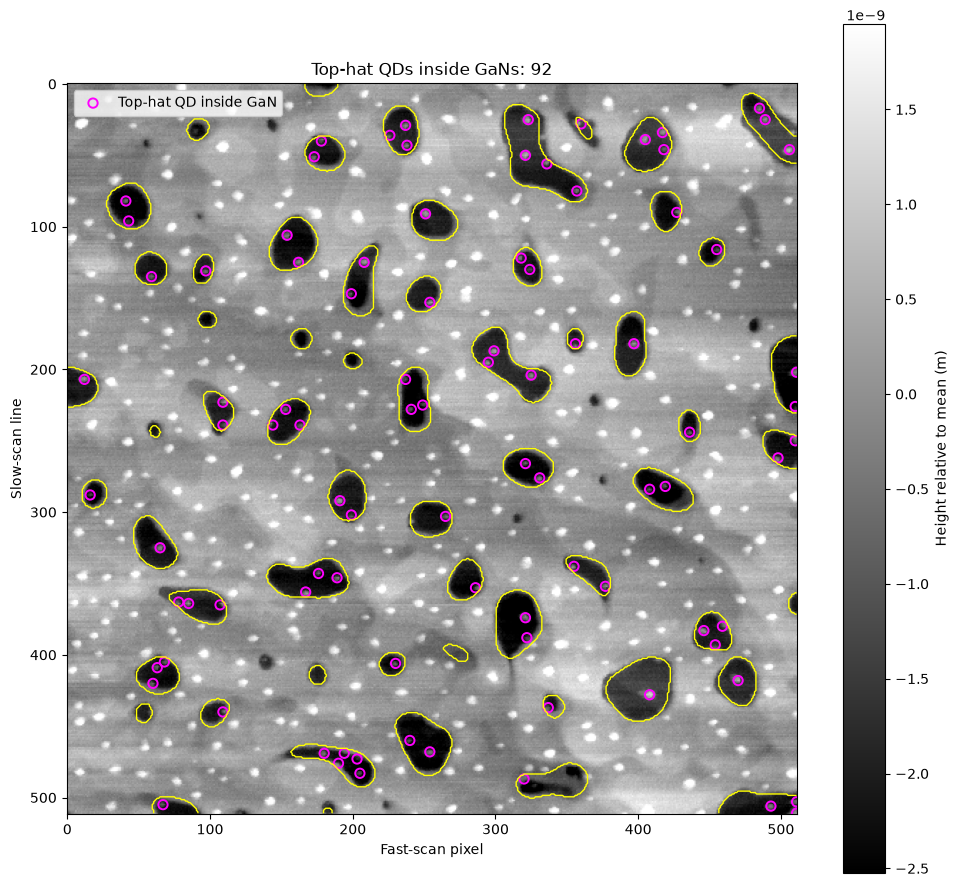

In [8]:
fig, ax = plt.subplots(figsize=(10, 9))

image_display = ax.imshow(
    z_nobackground,
    cmap="gray",
    vmin=np.nanpercentile( z_nobackground, 1,),
    vmax=np.nanpercentile( z_nobackground, 99, ),
)

ax.contour(GaN_mask, levels=[0.5], colors="yellow", linewidths=1.0,) #level 0.5 is the standard contour value used for evaluating the contour along a binary mask 

ax.scatter(
    inside_qd_x,
    inside_qd_y,
    s=45,
    facecolors="none",
    edgecolors="magenta",
    linewidths=1.4,
    label="Top-hat QD inside GaN",
)

ax.set_title(
    f"Top-hat QDs inside GaNs: "
    f"{len(inside_qd_y)}"
)

ax.set_xlabel("Fast-scan pixel")
ax.set_ylabel("Slow-scan line")

fig.colorbar( image_display, ax=ax, label="Height relative to mean (m)",)

ax.legend()
plt.tight_layout()
plt.show()

**4. Detecting QDs outside of the GaN layer, so these QDs will be on the InGaN layer:**

In [7]:
# Detect top-hat QDs outside GaNs

outside_mask = (~GaN_membership_mask & np.isfinite(z_nobackground))

tophat_outside_GaNs = np.where(outside_mask, tophat_map, 0.0,)

outside_values = tophat_outside_GaNs[outside_mask]
outside_values = outside_values[np.isfinite(outside_values)]

outside_tophat_threshold = np.nanpercentile(outside_values, 85,)

candidate_peaks_outside = peak_local_max(
    tophat_outside_GaNs,
    min_distance=3,
    threshold_abs=outside_tophat_threshold,
    exclude_border=False,
    labels=outside_mask.astype(np.uint8),
)

print("Top-hat candidates outside GaNs:", len(candidate_peaks_outside),)

Top-hat candidates outside GaNs: 1287


**5.  Validate outside candidates by local height**

In [8]:
minimum_dot_height = 6e-10

peak_radius = 2
ring_inner_radius = 3
ring_outer_radius = 7

outside_qd_y = []
outside_qd_x = []
outside_qd_heights = []


for candidate_y, candidate_x in candidate_peaks_outside:

    # Candidate must remain outside GaNs
    if GaN_membership_mask[candidate_y, candidate_x,]:
        continue

    y0 = max(0, candidate_y - ring_outer_radius,)
    y1 = min(z_nobackground.shape[0], candidate_y + ring_outer_radius + 1,)

    x0 = max(0, candidate_x - ring_outer_radius,)
    x1 = min(z_nobackground.shape[1], candidate_x + ring_outer_radius + 1,)

    local_height = z_nobackground[y0:y1, x0:x1,]
    local_membership = GaN_membership_mask[y0:y1, x0:x1,]

    yy, xx = np.ogrid[y0:y1, x0:x1,]
    rr2 = ((yy - candidate_y) ** 2 + (xx - candidate_x) ** 2)

    peak_mask = (rr2 <= peak_radius**2)

    ring_mask = ((rr2 >= ring_inner_radius**2) & (rr2 <= ring_outer_radius**2))

    # Use only non-GaN pixels for the outside background.
    outside_background_ring = (ring_mask & (~local_membership))

    peak_values = local_height[peak_mask]
    background_values = local_height[outside_background_ring]
    peak_values = peak_values[np.isfinite(peak_values)]
    background_values = background_values[np.isfinite(background_values)]

    if (peak_values.size == 0 or background_values.size < 8):
        continue

    local_peak = np.nanmax(peak_values)
    local_background = np.nanmedian(background_values)
    local_dot_height = (local_peak - local_background)

    if local_dot_height >= minimum_dot_height:
        outside_qd_y.append(candidate_y)
        outside_qd_x.append(candidate_x)
        outside_qd_heights.append(local_dot_height)


outside_qd_y = np.asarray(outside_qd_y, dtype=int,)
outside_qd_x = np.asarray(outside_qd_x, dtype=int,)

outside_qd_heights = np.asarray(outside_qd_heights, dtype=float,)

print("Accepted QDs outside GaNs:", len(outside_qd_y),)

if len(outside_qd_heights) > 0:
    print("Median outside QD height:", np.median(outside_qd_heights) * 1e9,"nm",)

Accepted QDs outside GaNs: 444
Median outside QD height: 1.85648825 nm


**6. Plot inside QDs in pink and outside QDs in orange**

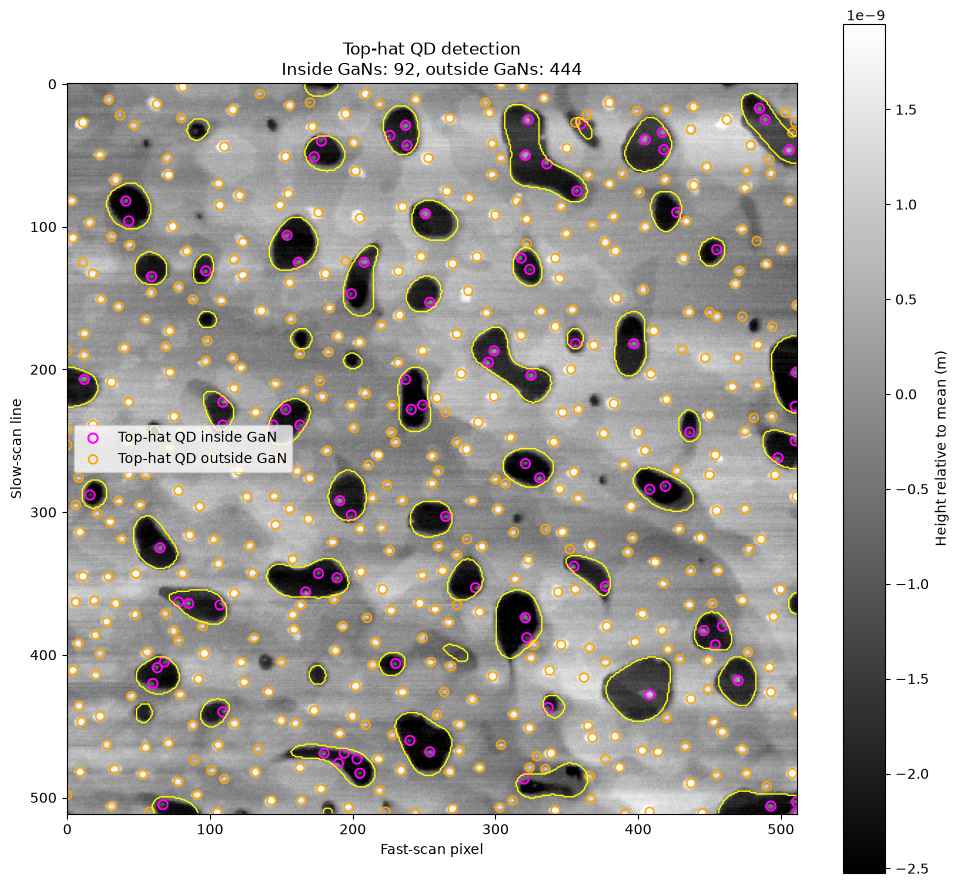

In [9]:
fig, ax = plt.subplots(
    figsize=(10, 9)
)

image_display = ax.imshow(
    z_nobackground,
    cmap="gray",
    vmin=np.nanpercentile( z_nobackground, 1,),
    vmax=np.nanpercentile( z_nobackground, 99, ),
)

ax.contour(GaN_mask, levels=[0.5], colors="yellow", linewidths=1.0,)

# Inside-GaN QDs
ax.scatter(
    inside_qd_x,
    inside_qd_y,
    s=45,
    facecolors="none",
    edgecolors="magenta",
    linewidths=1.4,
    label="Top-hat QD inside GaN",
)

# Outside-GaN QDs
ax.scatter(
    outside_qd_x,
    outside_qd_y,
    s=40,
    facecolors="none",
    edgecolors="orange",
    linewidths=1.2,
    label="Top-hat QD outside GaN",
)

ax.set_title(
    f"Top-hat QD detection\n"
    f"Inside GaNs: {len(inside_qd_y)}, "
    f"outside GaNs: {len(outside_qd_y)}"
)

ax.set_xlabel("Fast-scan pixel")
ax.set_ylabel("Slow-scan line")
fig.colorbar( image_display, ax=ax, label="Height relative to mean (m)",)
ax.legend()
plt.tight_layout()
plt.show()

Now, since we have 2 classes, we can compare if dots on GaN layer and dots on the InGaN layer are morphologically different. 

**To do this, lets compare:**
* local height above surrounding surface
* full width at half maximum in x and y
* equivalent diameter
* area above a relative-height threshold
* aspect ratio
* eccentricity
* circularity
* top-hat response strength
* local GaN depth for inside-GaN dots

# Comparing and Analysing QDs on GaN and InGaN layers

In [10]:
import numpy as np
import pandas as pd

from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects

In [11]:
geometry_radius = 8

# Segment each dot at this fraction of its local peak height.
relative_contour_fraction = 0.50
minimum_segment_area = 3

# Combine both QD classes
all_qd_y = np.concatenate([inside_qd_y, outside_qd_y,])
all_qd_x = np.concatenate([inside_qd_x, outside_qd_x,])

all_qd_class = np.concatenate(
    [
        np.full(len(inside_qd_y), "inside_GaN", dtype=object,),
        np.full(len(outside_qd_y), "outside_GaN",dtype=object,),
    ]
)

**1. Measure the selected properties of each QD**

In [12]:
# Measure each QD
qd_features = []

for qd_id, (centre_y, centre_x, qd_class,) in enumerate(
    zip(all_qd_y, all_qd_x, all_qd_class,), start=1,):

    y0 = max(0, centre_y - geometry_radius,)
    y1 = min(z_nobackground.shape[0], centre_y + geometry_radius + 1,)

    x0 = max(0, centre_x - geometry_radius,)
    x1 = min(z_nobackground.shape[1], centre_x + geometry_radius + 1,)

    patch = z_nobackground[y0:y1, x0:x1,]

    yy, xx = np.ogrid[y0:y1, x0:x1,]
    rr2 = ((yy - centre_y) ** 2 + (xx - centre_x) ** 2)

    background_ring = ((rr2 >= 5**2) & (rr2 <= geometry_radius**2))
    background_values = patch[background_ring]
    background_values = background_values[np.isfinite(background_values)]

    if background_values.size < 10:
        continue

    local_background = np.nanmedian(background_values)
    local_patch = (patch - local_background)
    local_peak = np.nanmax(local_patch)

    if (not np.isfinite(local_peak) or local_peak <= 0):
        continue

    contour_level = (relative_contour_fraction * local_peak)

    dot_binary = (local_patch >= contour_level)
    dot_binary = remove_small_objects(dot_binary, min_size=minimum_segment_area,)
    dot_labels = label(dot_binary)

    local_centre_y = (centre_y - y0)
    local_centre_x = (centre_x - x0)
    dot_label_at_centre = dot_labels[local_centre_y, local_centre_x,]

    # If the exact centre is not segmented, use the nearest segmented component to the detected peak.
    if dot_label_at_centre == 0:
        regions = regionprops(dot_labels)
        if len(regions) == 0:
            continue

        distances = []

        for region in regions:
            region_y, region_x = (region.centroid)
            distance = np.hypot(region_y - local_centre_y, region_x - local_centre_x,)
            distances.append(distance)

        selected_region = regions[np.argmin(distances)]

    else:
        selected_region = regionprops(dot_labels)[dot_label_at_centre - 1]


    area_pixels = selected_region.area
    equivalent_diameter = (selected_region.equivalent_diameter_area)
    major_axis = (selected_region.axis_major_length)
    minor_axis = (selected_region.axis_minor_length)
    eccentricity = (selected_region.eccentricity)
    perimeter = (selected_region.perimeter)

    if perimeter > 0:
        circularity = (4 * np.pi * area_pixels / perimeter**2)
    else:
        circularity = np.nan

    if minor_axis > 0:
        aspect_ratio = (major_axis / minor_axis)
    else:
        aspect_ratio = np.nan


    # Estimate FWHM directly from horizontal profile
    horizontal_profile = local_patch[local_centre_y,:]
    vertical_profile = local_patch[:, local_centre_x,]

    half_height = (0.5 * local_peak)

    horizontal_above = np.where(horizontal_profile >= half_height)[0]
    vertical_above = np.where(vertical_profile >= half_height)[0]

    if horizontal_above.size > 0:
        fwhm_x_pixels = (horizontal_above[-1] - horizontal_above[0] + 1)

    else:
        fwhm_x_pixels = np.nan

    if vertical_above.size > 0:
        fwhm_y_pixels = (vertical_above[-1] - vertical_above[0] + 1)

    else:
        fwhm_y_pixels = np.nan


    qd_features.append(
        {
            "qd_id": qd_id,
            "class": qd_class,
            "centre_y": centre_y,
            "centre_x": centre_x,
            "height_m": local_peak,
            "height_nm": local_peak * 1e9,
            "area_pixels": area_pixels,
            "equivalent_diameter_pixels":
                equivalent_diameter,
            "major_axis_pixels":
                major_axis,
            "minor_axis_pixels":
                minor_axis,
            "aspect_ratio":
                aspect_ratio,
            "eccentricity":
                eccentricity,
            "perimeter_pixels":
                perimeter,
            "circularity":
                circularity,
            "fwhm_x_pixels":
                fwhm_x_pixels,
            "fwhm_y_pixels":
                fwhm_y_pixels,
        }
    )

qd_feature_table = pd.DataFrame(qd_features)

print(qd_feature_table.head())
print("\nNumber of measured QDs by class:")
print(qd_feature_table["class"].value_counts())

   qd_id       class  centre_y  centre_x      height_m  height_nm  \
0      1  inside_GaN       511       511  2.316540e-09   2.316540   
1      2  inside_GaN       374       321  2.515302e-09   2.515302   
2      3  inside_GaN       428       408  2.507581e-09   2.507581   
3      4  inside_GaN        91       251  2.297198e-09   2.297198   
4      5  inside_GaN       202       511  2.201623e-09   2.201623   

   area_pixels  equivalent_diameter_pixels  major_axis_pixels  \
0         15.0                    4.370194           5.400372   
1         24.0                    5.527906           6.650234   
2         26.0                    5.753627           6.759031   
3         24.0                    5.527906           6.374067   
4         19.0                    4.918491           5.384892   

   minor_axis_pixels  aspect_ratio  eccentricity  perimeter_pixels  \
0           3.770114      1.432416      0.715980         12.828427   
1           4.725458      1.407321      0.703626      

/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_1870/2450607447.py:35: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  dot_binary = remove_small_objects(dot_binary, min_size=minimum_segment_area,)


**2. Comparing the QD parameters**

In [13]:
summary_table = (
    qd_feature_table
    .groupby("class")
    [
        [
            "height_nm",
            "area_pixels",
            "equivalent_diameter_pixels",
            "major_axis_pixels",
            "minor_axis_pixels",
            "aspect_ratio",
            "eccentricity",
            "circularity",
            "fwhm_x_pixels",
            "fwhm_y_pixels",
        ]
    ]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
        ]
    )
)

print(summary_table)

            height_nm                               area_pixels             \
                count      mean    median       std       count       mean   
class                                                                        
inside_GaN         92  2.353957  2.309321  0.605505          92  43.108696   
outside_GaN       437  1.938554  1.948849  0.388641         437  18.567506   

                              equivalent_diameter_pixels            ...  \
            median        std                      count      mean  ...   
class                                                               ...   
inside_GaN    26.5  35.453252                         92  6.722139  ...   
outside_GaN   18.0   8.340690                        437  4.744378  ...   

            circularity           fwhm_x_pixels                             \
                 median       std         count      mean median       std   
class                                                                        

**Height Distributions**

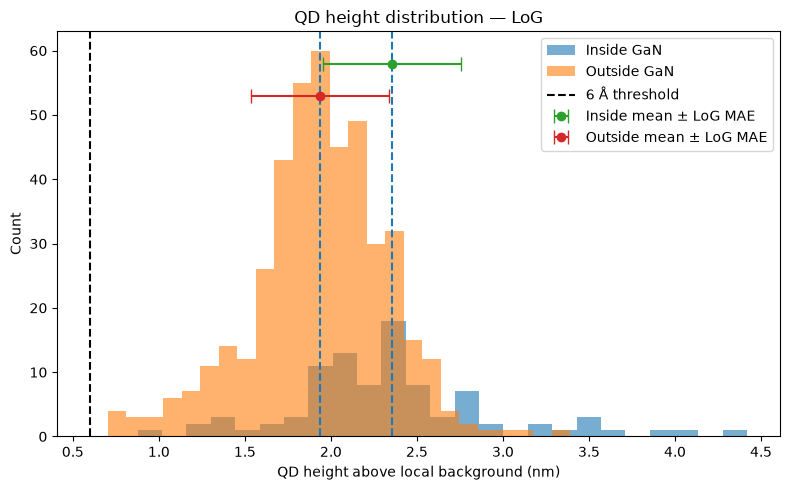

In [15]:
import numpy as np
import matplotlib.pyplot as plt


inside_heights = qd_feature_table.loc[
    qd_feature_table["class"] == "inside_GaN",
    "height_nm",
].to_numpy()

outside_heights = qd_feature_table.loc[
    qd_feature_table["class"] == "outside_GaN",
    "height_nm",
].to_numpy()


# FROM YOUR LoG ERROR TABLE
log_height_mae_nm = 0.40      # replace with actual number


inside_mean = np.mean(inside_heights)
outside_mean = np.mean(outside_heights)


fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.hist(
    inside_heights,
    bins=25,
    alpha=0.6,
    label="Inside GaN",
)

ax.hist(
    outside_heights,
    bins=25,
    alpha=0.6,
    label="Outside GaN",
)


# 6 Å HEIGHT THRESHOLD
ax.axvline(
    0.6,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="6 Å threshold",
)


# MEAN HEIGHTS
ax.axvline(
    inside_mean,
    linestyle="--",
    linewidth=1.5,
)

ax.axvline(
    outside_mean,
    linestyle="--",
    linewidth=1.5,
)


# ERROR BARS
ymax = ax.get_ylim()[1]

ax.errorbar(
    inside_mean,
    ymax * 0.92,
    xerr=log_height_mae_nm,
    fmt="o",
    capsize=5,
    label=f"Inside mean ± LoG MAE",
)

ax.errorbar(
    outside_mean,
    ymax * 0.84,
    xerr=log_height_mae_nm,
    fmt="o",
    capsize=5,
    label=f"Outside mean ± LoG MAE",
)


ax.set_xlabel(
    "QD height above local background (nm)"
)

ax.set_ylabel(
    "Count"
)

ax.set_title(
    "QD height distribution — LoG"
)

ax.legend()

plt.tight_layout()
plt.show()

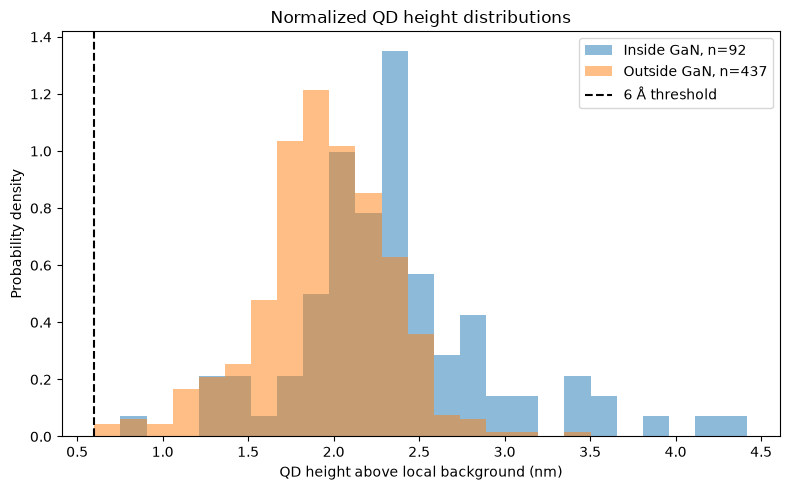

Minimum height in table: 0.7043405000000003 nm
Dots below 0.6 nm: 0


In [17]:
inside_heights_nm = qd_feature_table.loc[
    qd_feature_table["class"] == "inside_GaN",
    "height_nm",
]

outside_heights_nm = qd_feature_table.loc[
    qd_feature_table["class"] == "outside_GaN",
    "height_nm",
]


fig, ax = plt.subplots(
    figsize=(8, 5)
)

common_bins = np.linspace(
    0.6,
    max(
        inside_heights_nm.max(),
        outside_heights_nm.max(),
    ),
    26,
)

ax.hist(
    inside_heights_nm,
    bins=common_bins,
    density=True,
    alpha=0.5,
    label=f"Inside GaN, n={len(inside_heights_nm)}",
)

ax.hist(
    outside_heights_nm,
    bins=common_bins,
    density=True,
    alpha=0.5,
    label=f"Outside GaN, n={len(outside_heights_nm)}",
)

ax.axvline(
    0.6,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="6 Å threshold",
)

ax.set_xlabel(
    "QD height above local background (nm)"
)

ax.set_ylabel(
    "Probability density"
)

ax.set_title(
    "Normalized QD height distributions"
)

ax.legend()

plt.tight_layout()
plt.show()

print(
    "Minimum height in table:",
    qd_feature_table["height_nm"].min(),
    "nm",
)

print(
    "Dots below 0.6 nm:",
    np.sum(
        qd_feature_table["height_nm"] < 0.6
    ),
)

**Width distribution**

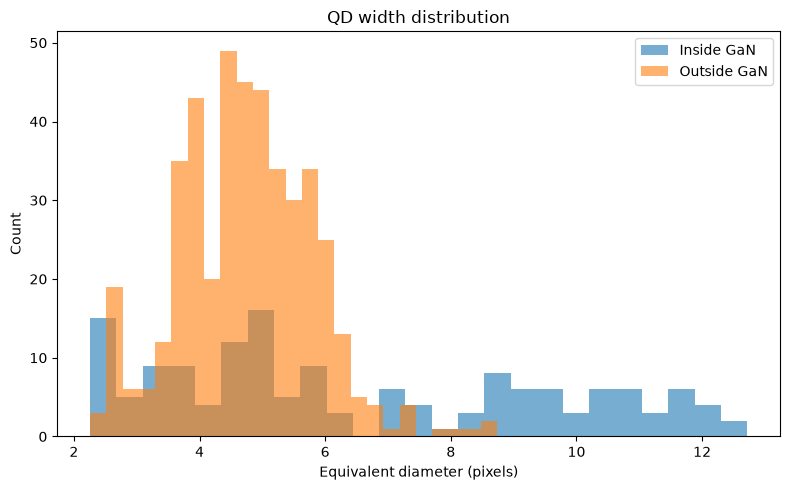

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    qd_feature_table.loc[
        qd_feature_table["class"]
        == "inside_GaN",
        "equivalent_diameter_pixels",
    ],
    bins=25,
    alpha=0.6,
    label="Inside GaN",
)

ax.hist(
    qd_feature_table.loc[
        qd_feature_table["class"]
        == "outside_GaN",
        "equivalent_diameter_pixels",
    ],
    bins=25,
    alpha=0.6,
    label="Outside GaN",
)

ax.set_xlabel("Equivalent diameter (pixels)")
ax.set_ylabel("Count")
ax.set_title("QD width distribution")
ax.legend()

plt.tight_layout()
plt.show()

**Height vs. Width**

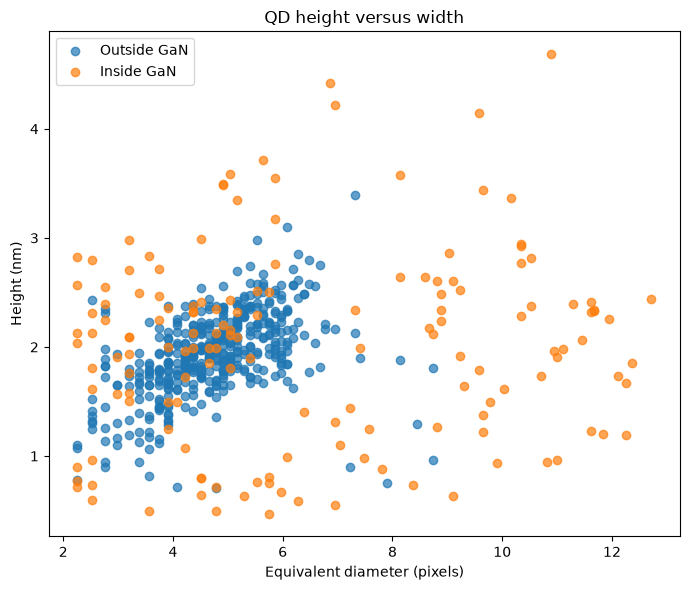

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))

inside_rows = (qd_feature_table["class"] == "inside_GaN")
outside_rows = (qd_feature_table["class"] == "outside_GaN")

ax.scatter(
    qd_feature_table.loc[outside_rows, "equivalent_diameter_pixels",],
    qd_feature_table.loc[outside_rows, "height_nm",],
    alpha=0.7,
    label="Outside GaN",
)

ax.scatter(
    qd_feature_table.loc[inside_rows, "equivalent_diameter_pixels",],
    qd_feature_table.loc[inside_rows, "height_nm",],
    alpha=0.7,
    label="Inside GaN",
)

ax.set_xlabel("Equivalent diameter (pixels)")
ax.set_ylabel("Height (nm)")
ax.set_title("QD height versus width")
ax.legend()

plt.tight_layout()
plt.show()

In [18]:
inside_radii = qd_feature_table.loc[
    qd_feature_table["class"] == "inside_GaN",
    "radius_px",
]

outside_radii = qd_feature_table.loc[
    qd_feature_table["class"] == "outside_GaN",
    "radius_px",
]

log_radius_mean_error_px = 0.8907

fig, ax = plt.subplots(figsize=(8, 5))

common_bins = np.linspace(
    min(inside_radii.min(), outside_radii.min()),
    max(inside_radii.max(), outside_radii.max()),
    26,
)

ax.hist(
    inside_radii,
    bins=common_bins,
    density=True,
    alpha=0.5,
    label=f"Inside GaN, n={len(inside_radii)}",
)

ax.hist(
    outside_radii,
    bins=common_bins,
    density=True,
    alpha=0.5,
    label=f"Outside GaN, n={len(outside_radii)}",
)

inside_mean = inside_radii.mean()
outside_mean = outside_radii.mean()

ymax = ax.get_ylim()[1]

ax.errorbar(
    inside_mean,
    ymax * 0.92,
    xerr=log_radius_mean_error_px,
    fmt="o",
    capsize=5,
    label="Inside mean ± LoG radius error",
)

ax.errorbar(
    outside_mean,
    ymax * 0.84,
    xerr=log_radius_mean_error_px,
    fmt="o",
    capsize=5,
    label="Outside mean ± LoG radius error",
)

ax.set_xlabel("QD radius (px)")
ax.set_ylabel("Probability density")
ax.set_title("Normalized QD radius distributions — LoG")
ax.legend()

plt.tight_layout()
plt.show()

KeyError: 'radius_px'